# Normalization Ablation and Graph Model Comparison

This notebook evaluates whether feature normalization affects `Omega_m` prediction and compares temporal EvolveGCN-H against a final-snapshot Static GCN baseline.

The goal is to summarize the controlled Top500 normalization ablation in a form suitable for thesis discussion and supervisor review.

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    """Find repository root from either the repo root or notebooks/visualization."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "experiments").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing experiments/ and src/.")


REPO_ROOT = find_repo_root()
EXP_DIR = REPO_ROOT / "experiments"
OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

print(f"Repository root: {REPO_ROOT}")
print(f"Experiments dir: {EXP_DIR}")
print(f"Outputs dir:     {OUT_DIR}")

Repository root: <REPO_ROOT>
Experiments dir: <REPO_ROOT>/experiments
Outputs dir:     <REPO_ROOT>/outputs


## 2. Research Question

This normalization ablation addresses three questions:

1. Does per-snapshot feature normalization help or hurt graph-based `Omega_m` prediction?
2. Is the temporal EvolveGCN-H model better than a simpler final-snapshot Static GCN?
3. Do the models learn the full `Omega_m` range, or do predictions collapse toward the mean?

## 3. Data and Graph Construction

Each universe is represented as a halo graph sample. Nodes are halos, and the Top500 halos are selected by raw `Mvir` before feature normalization. Node features are:

```text
[log10(Mvir), X, Y, Z, VX, VY, VZ]
```

Edges are constructed with periodic boundary-aware k-nearest neighbours using `k=8` and box size `25.0 h^-1 Mpc`. The target is the cosmological parameter `Omega_m`. This experiment uses 500 CAMELS-SIMBA universes.

```text
Raw halo catalogue
    ↓
Top500 halo selection by raw Mvir
    ↓
Node features:
[log10(Mvir), X, Y, Z, VX, VY, VZ]
    ↓
Periodic kNN graph construction
(k=8, box size=25.0)
    ↓
Feature normalization:
none / minmax / zscore
    ↓
Graph model
    ├── Static GCN:
    │       final snapshot only
    │       graph pooling
    │       regression head
    │
    └── EvolveGCN-H:
            five snapshots
            recurrently evolved GCN weights
            graph pooling per snapshot
            temporal pooling
            regression head
    ↓
Predicted Omega_m
```

## 4. Model Architectures

### Static GCN

```text
A, X, mask
→ normalized dense adjacency
→ input projection
→ DenseGCN layers
→ graph pooling
→ MLP regression head
→ Omega_m
```

The Static GCN uses only the final snapshot from the temporal dataset:

```text
A_list[-1], Nodes_list[-1], mask_list[-1]
```

### EvolveGCN-H

```text
A_seq, X_seq, mask_seq
→ EvolveGCN-H layers
→ graph pooling per snapshot
→ temporal pooling
→ MLP regression head
→ Omega_m
```

EvolveGCN-H uses all five snapshots and evolves GCN weights through time.

## 5. Experimental Design

The experiment compares three feature normalization settings:

- `none`
- `minmax`
- `zscore`

Each setting is evaluated over five random seeds: `42`, `123`, `999`, `2025`, and `777`. The datasets all use the same Top500 temporal graph family. Static GCN uses the final snapshot only, and split IDs are matched to the corresponding EvolveGCN-H experiment where applicable.

The main metrics are test MAE and test RMSE. Lower MAE is better.

## Graph Structure Diagnostics

The interactive 3D graph gives a qualitative view of the halo graph. These quantitative diagnostics check whether the graph is sparse or dense, whether the kNN construction behaves as expected, how halo masses are distributed, and whether graph connectivity is meaningful.

In [14]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd

# -----------------------------
# Robust repo paths
# -----------------------------
REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "visualization":
    REPO_ROOT = REPO_ROOT.parent.parent

OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def to_numpy_array(x):
    """Convert torch tensor or array-like object to numpy array."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_example_halo_graph(dataset_path: Path, snapshot_idx: int = -1):
    dataset_path = Path(dataset_path)

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_path}")

    dataset = torch.load(dataset_path, map_location="cpu", weights_only=False)

    if not isinstance(dataset, dict):
        raise TypeError(f"Expected dataset to be a dict keyed by LH IDs, got {type(dataset)}")

    universe_ids = sorted(dataset.keys(), key=lambda x: int(x.split("_")[1]))
    universe_id = universe_ids[0]
    sample = dataset[universe_id]

    required_keys = {"A_list", "Nodes_list", "mask_list", "target"}
    missing_keys = required_keys - set(sample.keys())

    if missing_keys:
        raise KeyError(f"Sample {universe_id} is missing keys: {sorted(missing_keys)}")

    A = sample["A_list"][snapshot_idx]
    X = sample["Nodes_list"][snapshot_idx]
    mask = sample["mask_list"][snapshot_idx]
    target = sample["target"]

    A = to_numpy_array(A)
    X = to_numpy_array(X)
    mask = to_numpy_array(mask)

    target_value = (
        float(target.detach().cpu().view(-1)[0])
        if torch.is_tensor(target)
        else float(np.asarray(target).reshape(-1)[0])
    )

    print(f"Dataset type: {type(dataset)}")
    print(f"Number of universes: {len(dataset)}")
    print(f"Selected universe: {universe_id}")
    print(f"A original shape: {A.shape}")
    print(f"X original shape: {X.shape}")
    print(f"mask original shape: {mask.shape}")

    # Remove singleton dimensions safely
    A = np.squeeze(A)
    X = np.squeeze(X)
    mask = np.squeeze(mask)

    print(f"A squeezed shape: {A.shape}")
    print(f"X squeezed shape: {X.shape}")
    print(f"mask squeezed shape: {mask.shape}")

    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError(f"Expected square adjacency matrix, got {A.shape}")

    if X.ndim != 2:
        raise ValueError(f"Expected 2D feature matrix, got {X.shape}")

    if X.shape[1] < 7:
        raise ValueError(f"Expected at least 7 feature columns, got {X.shape}")

    if A.shape[0] != X.shape[0]:
        raise ValueError(
            f"A node count {A.shape[0]} does not match X node count {X.shape[0]}"
        )

    # Fix mask shape: original known shape is often (500, 1)
    if mask.ndim == 0:
        print("Mask is scalar after squeeze; using all nodes.")
        mask = np.ones(X.shape[0], dtype=bool)
    else:
        mask = mask.reshape(-1).astype(bool)

    print(f"mask flattened shape: {mask.shape}")

    if mask.shape[0] == X.shape[0]:
        A = A[np.ix_(mask, mask)]
        X = X[mask]
    else:
        print(
            f"Mask length {mask.shape[0]} does not match node count {X.shape[0]}; "
            "using all nodes."
        )

    if A.shape[0] != X.shape[0]:
        raise ValueError(
            f"Masked A node count {A.shape[0]} does not match masked X node count {X.shape[0]}"
        )

    print(f"A final shape: {A.shape}")
    print(f"X final shape: {X.shape}")

    return universe_id, snapshot_idx, A, X, target_value


def periodic_edge_lengths(
    positions: np.ndarray,
    rows: np.ndarray,
    cols: np.ndarray,
    box_size: float,
) -> np.ndarray:
    """Compute periodic Euclidean edge lengths inside a cubic box."""
    delta = np.abs(positions[rows] - positions[cols])
    delta = np.minimum(delta, box_size - delta)
    return np.sqrt(np.sum(delta ** 2, axis=1))


graph_dataset_path = (
    REPO_ROOT
    / "data/processed/temporal_500u_none_top500_periodic_knn"
    / "camels_500u_temporal_logmass_none_top500_periodic_knn.pt"
)

universe_id, snapshot_idx, A_graph, X_graph, omega_m_target = load_example_halo_graph(
    graph_dataset_path,
    snapshot_idx=-1,
)

num_nodes = X_graph.shape[0]

# Unique undirected edges
rows, cols = np.where(np.triu(A_graph > 0, k=1))
num_edges = len(rows)

degree = (A_graph > 0).sum(axis=1)

graph_density = (
    (2 * num_edges) / (num_nodes * (num_nodes - 1))
    if num_nodes > 1
    else np.nan
)

log_mass = X_graph[:, 0]
positions = X_graph[:, 1:4]

edge_lengths = periodic_edge_lengths(
    positions,
    rows,
    cols,
    box_size=25.0,
)

summary_df = pd.DataFrame(
    [
        {
            "universe_id": universe_id,
            "omega_m_target": omega_m_target,
            "snapshot_index": snapshot_idx,
            "number_of_nodes": num_nodes,
            "number_of_undirected_edges": num_edges,
            "average_degree": float(np.mean(degree)),
            "minimum_degree": int(np.min(degree)),
            "maximum_degree": int(np.max(degree)),
            "graph_density": float(graph_density),
            "k_used": 8,
            "box_size": 25,
        }
    ]
)

summary_path = OUT_DIR / "graph_structure_summary_top500_none.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)

print(f"Saved graph structure summary to: {summary_path}")

Dataset type: <class 'dict'>
Number of universes: 500
Selected universe: LH_0
A original shape: (500, 500)
X original shape: (500, 7)
mask original shape: (500, 1)
A squeezed shape: (500, 500)
X squeezed shape: (500, 7)
mask squeezed shape: (500,)
mask flattened shape: (500,)
A final shape: (500, 500)
X final shape: (500, 7)


,universe_id,omega_m_target,snapshot_index,number_of_nodes,number_of_undirected_edges,average_degree,minimum_degree,maximum_degree,graph_density,k_used,box_size
0,LH_0,0.1462,-1,500,2539,10.156,8,17,0.020353,8,25


Saved graph structure summary to: <REPO_ROOT>/outputs/graph_structure_summary_top500_none.csv


### Degree Distribution

Because the graph is built with `k=8`, degrees should be around `k` or higher if the adjacency was symmetrized. This plot checks whether the graph is sparse and connected as expected.

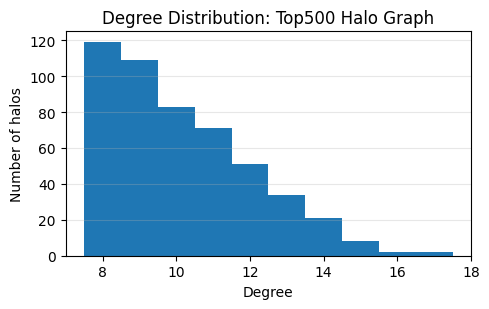

Saved degree distribution plot to: <REPO_ROOT>/outputs/graph_degree_distribution_top500_none.png


In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust paths
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "visualization":
    REPO_ROOT = REPO_ROOT.parent.parent

OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Recompute degree if it does not exist from previous cell
if "degree" not in globals():
    if "A_graph" not in globals():
        raise NameError("A_graph is not defined. Run the Graph Structure Summary cell first.")
    degree = (A_graph > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(5.0, 3.2))

bins = np.arange(degree.min(), degree.max() + 2) - 0.5
ax.hist(degree, bins=bins)

ax.set_title("Degree Distribution: Top500 Halo Graph")
ax.set_xlabel("Degree")
ax.set_ylabel("Number of halos")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

plot_path = OUT_DIR / "graph_degree_distribution_top500_none.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved degree distribution plot to: {plot_path}")

### Halo Mass Distribution

This verifies that the Top500 selection contains a broad mass range and that halo mass scale may carry `Omega_m` information. This is especially relevant because no-normalization performed best.

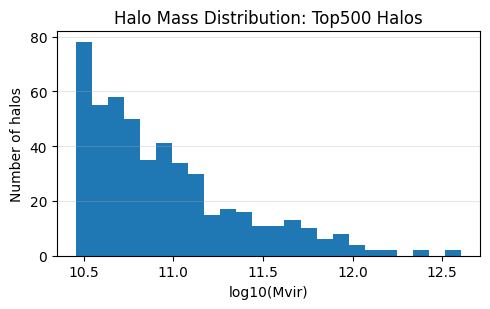

In [16]:
fig, ax = plt.subplots(figsize=(5.0, 3.2))
ax.hist(log_mass, bins=24)
ax.set_title("Halo Mass Distribution: Top500 Halos")
ax.set_xlabel("log10(Mvir)")
ax.set_ylabel("Number of halos")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "halo_mass_distribution_top500_none.png", dpi=200)
plt.show()

### Periodic Edge Length Distribution

Most edges should be relatively local, confirming kNN graph construction. Long edges may appear across periodic boundaries, but periodic distance accounts for the wrap-around geometry of the simulation box.

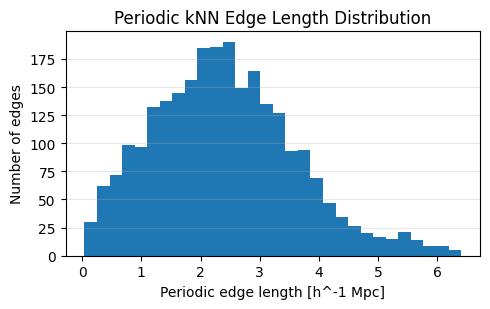

In [17]:
fig, ax = plt.subplots(figsize=(5.0, 3.2))
ax.hist(edge_lengths, bins=30)
ax.set_title("Periodic kNN Edge Length Distribution")
ax.set_xlabel("Periodic edge length [h^-1 Mpc]")
ax.set_ylabel("Number of edges")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "edge_length_distribution_top500_none.png", dpi=200)
plt.show()

### Halo Mass vs Graph Degree

This checks whether graph connectivity is related to halo mass. If massive halos have higher degree, the GNN may receive mass/connectivity correlations. If not, the graph is more spatially driven.

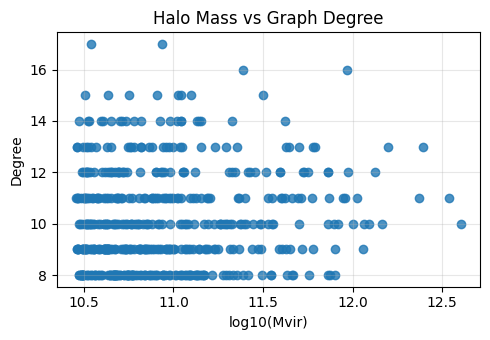

In [18]:
fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.scatter(log_mass, degree, alpha=0.8)
ax.set_title("Halo Mass vs Graph Degree")
ax.set_xlabel("log10(Mvir)")
ax.set_ylabel("Degree")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "mass_vs_degree_top500_none.png", dpi=200)
plt.show()

### XY Projection of Top500 Halos

This static projection is a PDF-friendly complement to the interactive 3D graph. Node color shows `log10(Mvir)`.

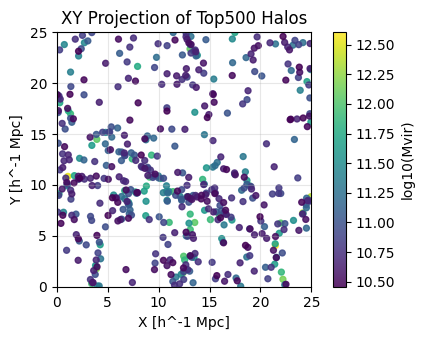

Saved XY projection plot to: <REPO_ROOT>/outputs/xy_projection_top500_none.png


In [20]:
from pathlib import Path
import matplotlib.pyplot as plt

# Robust paths
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "visualization":
    REPO_ROOT = REPO_ROOT.parent.parent

OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Safety check: these should come from the graph structure summary cell
required_vars = ["positions", "log_mass"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise NameError(
        f"Missing variables {missing_vars}. "
        "Run the Graph Structure Summary cell first."
    )

fig, ax = plt.subplots(figsize=(5.0, 3.5))

scatter = ax.scatter(
    positions[:, 0],
    positions[:, 1],
    c=log_mass,
    s=18,
    alpha=0.85,
)

ax.set_title("XY Projection of Top500 Halos")
ax.set_xlabel("X [h^-1 Mpc]")
ax.set_ylabel("Y [h^-1 Mpc]")
ax.set_xlim(0, 25)
ax.set_ylim(0, 25)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)

fig.colorbar(scatter, ax=ax, label="log10(Mvir)")

fig.tight_layout()

plot_path = OUT_DIR / "xy_projection_top500_none.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved XY projection plot to: {plot_path}")

## 6. EvolveGCN-H Normalization Ablation

This section tests whether preserving raw feature scale improves temporal graph regression. It loads the saved `metrics.json` files for all 15 EvolveGCN-H runs and summarizes test performance across seeds.

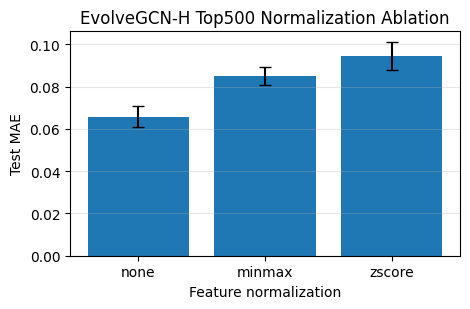

,model,normalization,seed,experiment_name,dataset_path,split_source,best_epoch,test_mae,test_rmse,status,warning
0,EvolveGCN-H,minmax,42,evolvegcn_h_500u_top500_h32_seed42,data/processed/temporal_500u_minmax_top500_per...,missing,69,0.081289,0.098849,ok,
1,EvolveGCN-H,minmax,123,evolvegcn_h_500u_top500_h32_seed123_minmax,data/processed/temporal_500u_minmax_top500_per...,missing,169,0.088085,0.105591,ok,
2,EvolveGCN-H,minmax,777,evolvegcn_h_500u_top500_h32_seed777_minmax,data/processed/temporal_500u_minmax_top500_per...,missing,97,0.079239,0.092654,ok,
3,EvolveGCN-H,minmax,999,evolvegcn_h_500u_top500_h32_seed999_minmax,data/processed/temporal_500u_minmax_top500_per...,missing,47,0.087262,0.103312,ok,
4,EvolveGCN-H,minmax,2025,evolvegcn_h_500u_top500_h32_seed2025_minmax,data/processed/temporal_500u_minmax_top500_per...,missing,101,0.089124,0.104102,ok,
5,EvolveGCN-H,none,42,evolvegcn_h_500u_top500_h32_seed42_none_norm,data/processed/temporal_500u_none_top500_perio...,missing,40,0.062224,0.074237,ok,
6,EvolveGCN-H,none,123,evolvegcn_h_500u_top500_h32_seed123_none,data/processed/temporal_500u_none_top500_perio...,missing,27,0.071179,0.085187,ok,
7,EvolveGCN-H,none,777,evolvegcn_h_500u_top500_h32_seed777_none,data/processed/temporal_500u_none_top500_perio...,missing,74,0.061948,0.074905,ok,
8,EvolveGCN-H,none,999,evolvegcn_h_500u_top500_h32_seed999_none,data/processed/temporal_500u_none_top500_perio...,missing,28,0.071192,0.088952,ok,
9,EvolveGCN-H,none,2025,evolvegcn_h_500u_top500_h32_seed2025_none,data/processed/temporal_500u_none_top500_perio...,missing,163,0.062445,0.076875,ok,


,normalization,count,mean_mae,std_mae,min_mae,max_mae,mean_rmse,std_rmse
0,none,5,0.065798,0.004922,0.061948,0.071192,0.080031,0.006633
1,minmax,5,0.085000,0.004433,0.079239,0.089124,0.100902,0.005251
2,zscore,5,0.094548,0.006507,0.087933,0.105329,0.110390,0.006194


In [12]:
EVOLVEGCN_EXPERIMENTS = {
    "minmax": {
        42: "evolvegcn_h_500u_top500_h32_seed42",
        123: "evolvegcn_h_500u_top500_h32_seed123_minmax",
        999: "evolvegcn_h_500u_top500_h32_seed999_minmax",
        2025: "evolvegcn_h_500u_top500_h32_seed2025_minmax",
        777: "evolvegcn_h_500u_top500_h32_seed777_minmax",
    },
    "none": {
        42: "evolvegcn_h_500u_top500_h32_seed42_none_norm",
        123: "evolvegcn_h_500u_top500_h32_seed123_none",
        999: "evolvegcn_h_500u_top500_h32_seed999_none",
        2025: "evolvegcn_h_500u_top500_h32_seed2025_none",
        777: "evolvegcn_h_500u_top500_h32_seed777_none",
    },
    "zscore": {
        42: "evolvegcn_h_500u_top500_h32_seed42_zscore",
        123: "evolvegcn_h_500u_top500_h32_seed123_zscore",
        999: "evolvegcn_h_500u_top500_h32_seed999_zscore",
        2025: "evolvegcn_h_500u_top500_h32_seed2025_zscore",
        777: "evolvegcn_h_500u_top500_h32_seed777_zscore",
    },
}


def load_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_experiment_metrics(experiment_map: dict, model_name: str) -> pd.DataFrame:
    rows = []
    for normalization, seed_to_experiment in experiment_map.items():
        for seed, experiment_name in seed_to_experiment.items():
            exp_path = EXP_DIR / experiment_name
            metrics_path = exp_path / "metrics.json"
            config_path = exp_path / "config.json"
            metrics = load_json(metrics_path)
            config = load_json(config_path)

            status = "ok"
            warning = ""
            test_mae = np.nan
            test_rmse = np.nan
            best_epoch = np.nan
            dataset_path = "missing"
            split_source = "missing"

            if metrics is None:
                status = "missing_metrics"
                warning = f"Missing {metrics_path.relative_to(REPO_ROOT)}"
            else:
                test = metrics.get("test", {})
                test_mae = test.get("mae", np.nan)
                test_rmse = test.get("rmse", np.nan)
                best_epoch = metrics.get("best_epoch", np.nan)

            if config is None:
                if warning:
                    warning += "; "
                warning += f"Missing {config_path.relative_to(REPO_ROOT)}"
            else:
                dataset_path = config.get("dataset_path", "missing")
                split_source = config.get("split_source", "missing")

            rows.append(
                {
                    "model": model_name,
                    "normalization": normalization,
                    "seed": seed,
                    "experiment_name": experiment_name,
                    "dataset_path": dataset_path,
                    "split_source": split_source,
                    "best_epoch": best_epoch,
                    "test_mae": test_mae,
                    "test_rmse": test_rmse,
                    "status": status,
                    "warning": warning,
                }
            )
    return pd.DataFrame(rows).sort_values(["normalization", "seed"]).reset_index(drop=True)


def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    ok = df[df["status"].eq("ok")].copy()
    summary = (
        ok.groupby("normalization", as_index=False)
        .agg(
            count=("test_mae", "count"),
            mean_mae=("test_mae", "mean"),
            std_mae=("test_mae", "std"),
            min_mae=("test_mae", "min"),
            max_mae=("test_mae", "max"),
            mean_rmse=("test_rmse", "mean"),
            std_rmse=("test_rmse", "std"),
        )
        .sort_values("mean_mae")
        .reset_index(drop=True)
    )
    return summary


def plot_normalization_bar(summary: pd.DataFrame, title: str, output_path: Path) -> None:
    plot_df = summary.set_index("normalization").reindex(["none", "minmax", "zscore"]).dropna(subset=["mean_mae"])
    fig, ax = plt.subplots(figsize=(4.8, 3.2))
    ax.bar(plot_df.index, plot_df["mean_mae"], yerr=plot_df["std_mae"], capsize=4)
    ax.set_title(title)
    ax.set_xlabel("Feature normalization")
    ax.set_ylabel("Test MAE")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


evolvegcn_df = load_experiment_metrics(EVOLVEGCN_EXPERIMENTS, "EvolveGCN-H")
evolvegcn_summary = summarize_metrics(evolvegcn_df)

evolvegcn_df.to_csv(OUT_DIR / "evolvegcn_h_normalization_top500_5seeds.csv", index=False)
evolvegcn_summary.to_csv(OUT_DIR / "evolvegcn_h_normalization_top500_5seeds_summary.csv", index=False)
plot_normalization_bar(
    evolvegcn_summary,
    "EvolveGCN-H Top500 Normalization Ablation",
    OUT_DIR / "evolvegcn_h_normalization_top500_5seeds_mae.png",
)

display(evolvegcn_df)
display(evolvegcn_summary)

## 7. Static GCN Normalization Ablation

The Static GCN is a final-snapshot graph baseline. It tests whether the normalization effect also appears without temporal modeling.

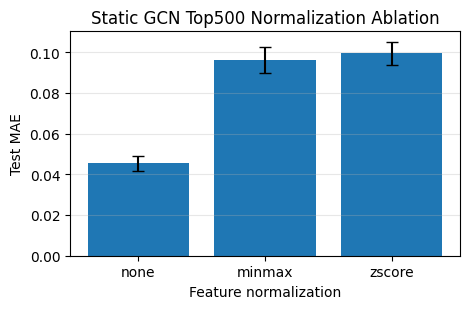

,model,normalization,seed,experiment_name,dataset_path,split_source,best_epoch,test_mae,test_rmse,status,warning
0,Static GCN,minmax,42,static_gcn_top500_final_snapshot_same_split_h3...,data/processed/temporal_500u_minmax_top500_per...,experiments/evolvegcn_h_500u_top500_h32_seed42...,16,0.086305,0.101537,ok,
1,Static GCN,minmax,123,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_minmax_top500_per...,experiments/evolvegcn_h_500u_top500_h32_seed12...,13,0.097980,0.113879,ok,
2,Static GCN,minmax,777,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_minmax_top500_per...,experiments/evolvegcn_h_500u_top500_h32_seed77...,10,0.097587,0.114538,ok,
3,Static GCN,minmax,999,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_minmax_top500_per...,experiments/evolvegcn_h_500u_top500_h32_seed99...,24,0.094225,0.111318,ok,
4,Static GCN,minmax,2025,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_minmax_top500_per...,experiments/evolvegcn_h_500u_top500_h32_seed20...,5,0.103833,0.119844,ok,
5,Static GCN,none,42,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_none_top500_perio...,experiments/evolvegcn_h_500u_top500_h32_seed42...,91,0.042808,0.054733,ok,
6,Static GCN,none,123,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_none_top500_perio...,experiments/evolvegcn_h_500u_top500_h32_seed12...,74,0.042267,0.051885,ok,
7,Static GCN,none,777,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_none_top500_perio...,experiments/evolvegcn_h_500u_top500_h32_seed77...,48,0.044509,0.054390,ok,
8,Static GCN,none,999,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_none_top500_perio...,experiments/evolvegcn_h_500u_top500_h32_seed99...,88,0.051583,0.065103,ok,
9,Static GCN,none,2025,static_gcn_500u_top500_final_snapshot_h32_seed...,data/processed/temporal_500u_none_top500_perio...,experiments/evolvegcn_h_500u_top500_h32_seed20...,150,0.045354,0.056926,ok,


,normalization,count,mean_mae,std_mae,min_mae,max_mae,mean_rmse,std_rmse
0,none,5,0.045304,0.003725,0.042267,0.051583,0.056607,0.005074
1,minmax,5,0.095986,0.006421,0.086305,0.103833,0.112223,0.006731
2,zscore,5,0.099335,0.005608,0.092762,0.104705,0.116358,0.005564


In [13]:
STATIC_GCN_EXPERIMENTS = {
    "minmax": {
        42: "static_gcn_top500_final_snapshot_same_split_h32_seed42",
        123: "static_gcn_500u_top500_final_snapshot_h32_seed123_minmax",
        999: "static_gcn_500u_top500_final_snapshot_h32_seed999_minmax",
        2025: "static_gcn_500u_top500_final_snapshot_h32_seed2025_minmax",
        777: "static_gcn_500u_top500_final_snapshot_h32_seed777_minmax",
    },
    "none": {
        42: "static_gcn_500u_top500_final_snapshot_h32_seed42_none",
        123: "static_gcn_500u_top500_final_snapshot_h32_seed123_none",
        999: "static_gcn_500u_top500_final_snapshot_h32_seed999_none",
        2025: "static_gcn_500u_top500_final_snapshot_h32_seed2025_none",
        777: "static_gcn_500u_top500_final_snapshot_h32_seed777_none",
    },
    "zscore": {
        42: "static_gcn_500u_top500_final_snapshot_h32_seed42_zscore",
        123: "static_gcn_500u_top500_final_snapshot_h32_seed123_zscore",
        999: "static_gcn_500u_top500_final_snapshot_h32_seed999_zscore",
        2025: "static_gcn_500u_top500_final_snapshot_h32_seed2025_zscore",
        777: "static_gcn_500u_top500_final_snapshot_h32_seed777_zscore",
    },
}

static_gcn_df = load_experiment_metrics(STATIC_GCN_EXPERIMENTS, "Static GCN")
static_gcn_summary = summarize_metrics(static_gcn_df)

static_gcn_df.to_csv(OUT_DIR / "static_gcn_normalization_top500_5seeds.csv", index=False)
static_gcn_summary.to_csv(OUT_DIR / "static_gcn_normalization_top500_5seeds_summary.csv", index=False)
plot_normalization_bar(
    static_gcn_summary,
    "Static GCN Top500 Normalization Ablation",
    OUT_DIR / "static_gcn_normalization_top500_5seeds_mae.png",
)

display(static_gcn_df)
display(static_gcn_summary)

## 8. Combined Model Comparison

This section compares both graph architectures directly across the same normalization settings.

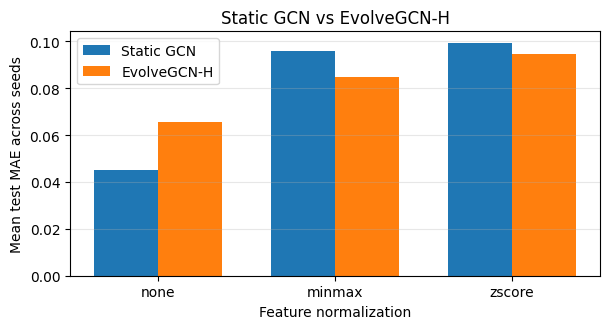

,Model,None MAE,Minmax MAE,Zscore MAE
0,EvolveGCN-H,0.065798,0.085000,0.094548
1,Static GCN,0.045304,0.095986,0.099335


In [14]:
def summary_to_row(summary: pd.DataFrame, model_name: str) -> dict:
    indexed = summary.set_index("normalization")
    return {
        "Model": model_name,
        "None MAE": indexed.loc["none", "mean_mae"] if "none" in indexed.index else np.nan,
        "Minmax MAE": indexed.loc["minmax", "mean_mae"] if "minmax" in indexed.index else np.nan,
        "Zscore MAE": indexed.loc["zscore", "mean_mae"] if "zscore" in indexed.index else np.nan,
    }

comparison_df = pd.DataFrame(
    [
        summary_to_row(evolvegcn_summary, "EvolveGCN-H"),
        summary_to_row(static_gcn_summary, "Static GCN"),
    ]
)
comparison_df.to_csv(OUT_DIR / "static_vs_evolvegcn_h_normalization_comparison.csv", index=False)

plot_rows = []
for _, row in comparison_df.iterrows():
    for normalization, column in [("none", "None MAE"), ("minmax", "Minmax MAE"), ("zscore", "Zscore MAE")]:
        plot_rows.append({"Model": row["Model"], "normalization": normalization, "mean_mae": row[column]})
plot_df = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
normalizations = ["none", "minmax", "zscore"]
x = np.arange(len(normalizations))
width = 0.36
for offset, model_name in [(-width / 2, "Static GCN"), (width / 2, "EvolveGCN-H")]:
    values = [
        plot_df[(plot_df["Model"].eq(model_name)) & (plot_df["normalization"].eq(norm))]["mean_mae"].iloc[0]
        for norm in normalizations
    ]
    ax.bar(x + offset, values, width=width, label=model_name)

ax.set_title("Static GCN vs EvolveGCN-H")
ax.set_xlabel("Feature normalization")
ax.set_ylabel("Mean test MAE across seeds")
ax.set_xticks(x)
ax.set_xticklabels(normalizations)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "static_vs_evolvegcn_h_normalization_comparison.png", dpi=200)
plt.show()

display(comparison_df)

## 9. Prediction Behaviour Diagnostics

Accuracy alone is not enough. We also inspect whether predictions span the true `Omega_m` range or collapse toward the mean.

Diagnostics used here:

- True vs predicted scatter plot
- Residual plot
- Prediction distribution histogram
- Collapse ratio: `std(predictions) / std(targets)`

A collapse ratio near 1 means predictions use a similar range to the target. A much smaller ratio means prediction compression.

In [15]:
def load_prediction_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing prediction CSV: {path}")
    df = pd.read_csv(path)
    required = {"true_omega_m", "pred_omega_m", "absolute_error", "squared_error"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Prediction CSV {path} is missing columns: {sorted(missing)}")
    return df


def prediction_behavior_table(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    y_true = df["true_omega_m"].to_numpy(dtype=float)
    y_pred = df["pred_omega_m"].to_numpy(dtype=float)
    residual = y_pred - y_true

    target_std = float(np.std(y_true, ddof=1))
    pred_std = float(np.std(y_pred, ddof=1))
    pearson = float(np.corrcoef(y_true, y_pred)[0, 1]) if len(df) > 1 and target_std > 0 and pred_std > 0 else np.nan

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "num_samples": len(df),
                "target_mean": float(np.mean(y_true)),
                "target_std": target_std,
                "prediction_mean": float(np.mean(y_pred)),
                "prediction_std": pred_std,
                "prediction_min": float(np.min(y_pred)),
                "prediction_max": float(np.max(y_pred)),
                "mae": float(np.mean(np.abs(residual))),
                "rmse": float(np.sqrt(np.mean(residual ** 2))),
                "collapse_ratio": pred_std / target_std if target_std > 0 else np.nan,
                "pearson_correlation": pearson,
            }
        ]
    )


def save_prediction_plots(df: pd.DataFrame, model_name: str, prefix: str) -> pd.DataFrame:
    y_true = df["true_omega_m"].to_numpy(dtype=float)
    y_pred = df["pred_omega_m"].to_numpy(dtype=float)
    residual = y_pred - y_true

    behavior = prediction_behavior_table(df, model_name)
    behavior.to_csv(OUT_DIR / f"{prefix}_prediction_behavior.csv", index=False)

    lim_min = min(float(y_true.min()), float(y_pred.min()))
    lim_max = max(float(y_true.max()), float(y_pred.max()))

    fig, ax = plt.subplots(figsize=(4.4, 4.0))
    ax.scatter(y_true, y_pred, alpha=0.8)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", linewidth=1)
    ax.set_title(f"{model_name}: True vs Predicted")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Predicted Omega_m")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{prefix}_true_vs_pred.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(4.8, 3.2))
    ax.scatter(y_true, residual, alpha=0.8)
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_title(f"{model_name}: Residuals")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Prediction - target")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{prefix}_residuals.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(4.8, 3.2))
    ax.hist(y_true, bins=16, alpha=0.6, label="Target")
    ax.hist(y_pred, bins=16, alpha=0.6, label="Prediction")
    ax.set_title(f"{model_name}: Prediction Distribution")
    ax.set_xlabel("Omega_m")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{prefix}_prediction_distribution.png", dpi=200)
    plt.show()

    return behavior

## 10. EvolveGCN-H Prediction Behaviour

This section inspects the seed-42 EvolveGCN-H model trained without feature normalization.

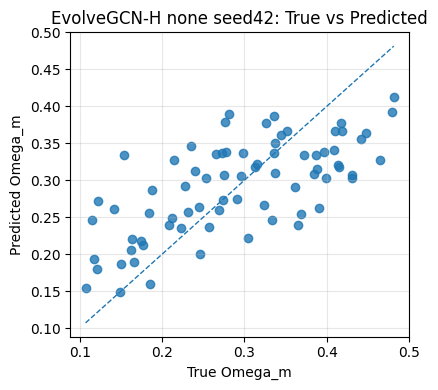

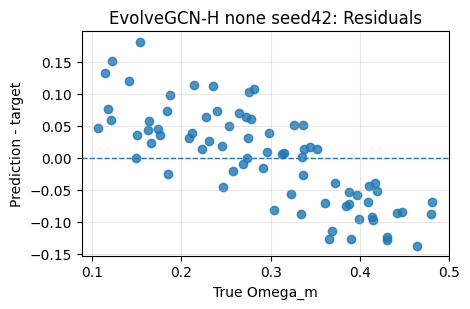

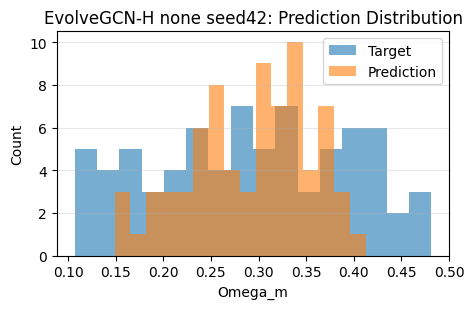

,model,num_samples,target_mean,target_std,prediction_mean,prediction_std,prediction_min,prediction_max,mae,rmse,collapse_ratio,pearson_correlation
0,EvolveGCN-H none seed42,75,0.291693,0.102025,0.292247,0.063264,0.148814,0.412312,0.062224,0.074237,0.620082,0.683718


In [16]:
evolvegcn_pred_path = EXP_DIR / "evolvegcn_h_500u_top500_h32_seed42_none_norm" / "predictions" / "test_predictions.csv"
evolvegcn_pred_df = load_prediction_csv(evolvegcn_pred_path)
evolvegcn_behavior = save_prediction_plots(
    evolvegcn_pred_df,
    "EvolveGCN-H none seed42",
    "evolvegcn_h_none_seed42",
)
display(evolvegcn_behavior)

## 11. Static GCN Prediction Behaviour

This section inspects the seed-42 Static GCN model trained on the final snapshot without feature normalization.

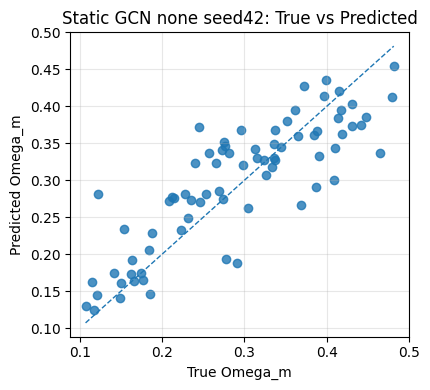

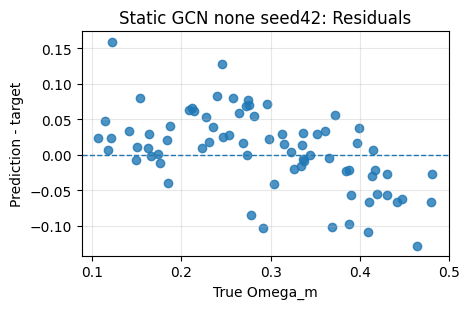

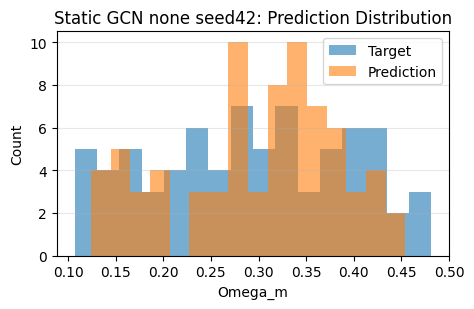

,model,num_samples,target_mean,target_std,prediction_mean,prediction_std,prediction_min,prediction_max,mae,rmse,collapse_ratio,pearson_correlation
0,Static GCN none seed42,75,0.291693,0.102025,0.298097,0.085393,0.124091,0.453959,0.042808,0.054733,0.836977,0.844015


In [17]:
static_pred_path = EXP_DIR / "static_gcn_500u_top500_final_snapshot_h32_seed42_none" / "predictions" / "test_predictions.csv"
static_pred_df = load_prediction_csv(static_pred_path)
static_behavior = save_prediction_plots(
    static_pred_df,
    "Static GCN none seed42",
    "static_gcn_none_seed42",
)
display(static_behavior)

## Sorted Target vs Prediction Curve

The test universes are sorted by true `Omega_m`, then true and predicted `Omega_m` are plotted as two curves. If predictions follow the true curve, the model captures the target ordering. If predictions flatten, the model is compressing predictions toward the mean.

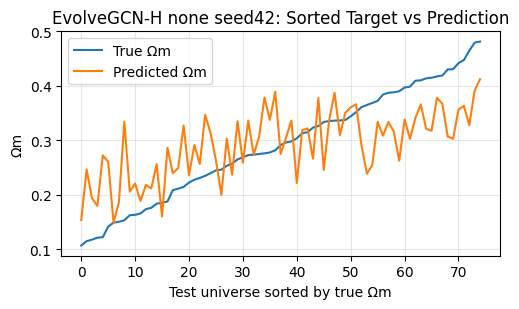

Saved sorted prediction plot to: <REPO_ROOT>/outputs/evolvegcn_h_none_seed42_sorted_true_vs_pred_curve.png


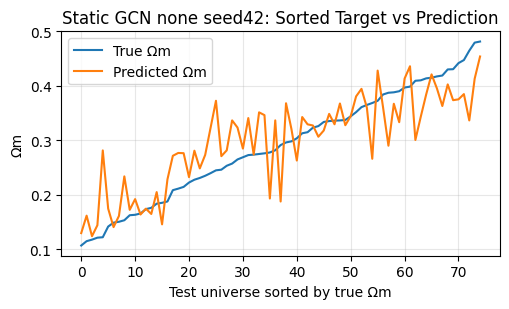

Saved sorted prediction plot to: <REPO_ROOT>/outputs/static_gcn_none_seed42_sorted_true_vs_pred_curve.png


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make paths work both from repo root and from notebooks/visualization
ROOT = Path.cwd()

if ROOT.name == "visualization":
    ROOT = ROOT.parent.parent

EXP_DIR = ROOT / "experiments"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def plot_sorted_predictions(prediction_csv: Path, title: str, output_path: Path) -> None:
    prediction_csv = Path(prediction_csv)
    output_path = Path(output_path)

    if not prediction_csv.exists():
        raise FileNotFoundError(f"Missing prediction CSV: {prediction_csv}")

    df = pd.read_csv(prediction_csv)

    required = {"true_omega_m", "pred_omega_m", "absolute_error", "squared_error"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(
            f"Prediction CSV {prediction_csv} is missing columns: {sorted(missing)}"
        )

    sorted_df = df.sort_values("true_omega_m").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    ax.plot(sorted_df.index, sorted_df["true_omega_m"], label="True Ωm")
    ax.plot(sorted_df.index, sorted_df["pred_omega_m"], label="Predicted Ωm")

    ax.set_title(title)
    ax.set_xlabel("Test universe sorted by true Ωm")
    ax.set_ylabel("Ωm")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved sorted prediction plot to: {output_path}")


plot_sorted_predictions(
    EXP_DIR / "evolvegcn_h_500u_top500_h32_seed42_none_norm" / "predictions" / "test_predictions.csv",
    "EvolveGCN-H none seed42: Sorted Target vs Prediction",
    OUT_DIR / "evolvegcn_h_none_seed42_sorted_true_vs_pred_curve.png",
)

plot_sorted_predictions(
    EXP_DIR / "static_gcn_500u_top500_final_snapshot_h32_seed42_none" / "predictions" / "test_predictions.csv",
    "Static GCN none seed42: Sorted Target vs Prediction",
    OUT_DIR / "static_gcn_none_seed42_sorted_true_vs_pred_curve.png",
)

## Interactive 3D Halo Graph Visualization

This figure visualizes one CAMELS-SIMBA universe as a 3D halo graph.

Each node is one halo from the Top500 selection. The node coordinates are the physical halo positions \(X, Y, Z\) inside the \(25\,h^{-1}\mathrm{Mpc}\) simulation box. Edges come from the periodic kNN graph construction with \(k=8\).

This visualization is used only for qualitative inspection of the graph structure and the spatial distribution of halos.

A model with complete collapse would appear almost flat. A good model should follow the rising true `Omega_m` curve. The Static GCN curve is expected to follow the true curve more closely than EvolveGCN-H, consistent with its lower MAE and higher collapse ratio. This plot complements the scatter plot, residual plot, and prediction distribution histogram.

In [10]:
from pathlib import Path
import torch
import numpy as np
import plotly.graph_objects as go

# -----------------------------
# Robust repo paths
# -----------------------------
ROOT = Path.cwd()
if ROOT.name == "visualization":
    ROOT = ROOT.parent.parent

DATASET_PATH = (
    ROOT
    / "data/processed/temporal_500u_none_top500_periodic_knn"
    / "camels_500u_temporal_logmass_none_top500_periodic_knn.pt"
)

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

# -----------------------------
# Load dataset
# -----------------------------
dataset = torch.load(DATASET_PATH, map_location="cpu")

print(type(dataset))
print(f"Number of universes: {len(dataset)}")

# -----------------------------
# Select universe and snapshot
# -----------------------------
sample_idx = 0
snapshot_idx = -1  # final snapshot

if isinstance(dataset, dict):
    universe_ids = sorted(dataset.keys(), key=lambda x: int(x.split("_")[1]))
    universe_id = universe_ids[sample_idx]
    sample = dataset[universe_id]
else:
    universe_id = f"index_{sample_idx}"
    sample = dataset[sample_idx]

print(f"Selected universe: {universe_id}")

# -----------------------------
# Extract graph snapshot
# -----------------------------
A = sample["A_list"][snapshot_idx]
X = sample["Nodes_list"][snapshot_idx]
mask = sample["mask_list"][snapshot_idx]
target = sample["target"]

# Convert to numpy
A = A.detach().cpu().numpy()
X = X.detach().cpu().numpy()
mask = mask.detach().cpu().numpy()

print("Original shapes:")
print("A:", A.shape)
print("X:", X.shape)
print("mask:", mask.shape)

# -----------------------------
# Fix shapes safely
# -----------------------------
A = np.squeeze(A)
X = np.squeeze(X)
mask = np.squeeze(mask)

# If mask becomes scalar, ignore it
if mask.ndim == 0:
    mask = np.ones(X.shape[0], dtype=bool)
else:
    mask = mask.reshape(-1).astype(bool)

print("After squeeze:")
print("A:", A.shape)
print("X:", X.shape)
print("mask:", mask.shape)

# Validate feature matrix
if X.ndim != 2:
    raise ValueError(f"Expected X to be 2D after squeeze, got shape {X.shape}")

if X.shape[1] < 4:
    raise ValueError(f"Expected at least 4 feature columns, got X shape {X.shape}")

# Validate adjacency
if A.ndim != 2 or A.shape[0] != A.shape[1]:
    raise ValueError(f"Expected square adjacency matrix, got shape {A.shape}")

# Apply mask only if it matches node count
num_nodes = X.shape[0]

if len(mask) == num_nodes:
    X = X[mask]
    A = A[mask][:, mask]
else:
    print(
        f"Warning: mask length {len(mask)} does not match node count {num_nodes}. "
        "Skipping mask."
    )

print("Final shapes:")
print("A:", A.shape)
print("X:", X.shape)

# -----------------------------
# Feature columns
# -----------------------------
log_mass = X[:, 0]
x_pos = X[:, 1]
y_pos = X[:, 2]
z_pos = X[:, 3]

print(f"Universe ID: {universe_id}")
print(f"Snapshot index: {snapshot_idx}")
print(f"Number of plotted halos: {len(X)}")
print(f"Omega_m target: {float(target):.4f}")
print("Position ranges:")
print(f"X: {x_pos.min():.3f} to {x_pos.max():.3f}")
print(f"Y: {y_pos.min():.3f} to {y_pos.max():.3f}")
print(f"Z: {z_pos.min():.3f} to {z_pos.max():.3f}")

# -----------------------------
# Build edge traces
# -----------------------------
edge_x, edge_y, edge_z = [], [], []

rows, cols = np.where(A > 0)
seen = set()

max_edges = 2500
edge_count = 0

for i, j in zip(rows, cols):
    if i == j:
        continue

    key = tuple(sorted((int(i), int(j))))
    if key in seen:
        continue

    seen.add(key)

    edge_x += [x_pos[i], x_pos[j], None]
    edge_y += [y_pos[i], y_pos[j], None]
    edge_z += [z_pos[i], z_pos[j], None]

    edge_count += 1
    if edge_count >= max_edges:
        break

print(f"Plotted edges: {edge_count}")

# -----------------------------
# Plotly traces
# -----------------------------
edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode="lines",
    line=dict(width=1),
    opacity=0.18,
    name="kNN edges",
)

node_trace = go.Scatter3d(
    x=x_pos,
    y=y_pos,
    z=z_pos,
    mode="markers",
    marker=dict(
        size=4,
        color=log_mass,
        colorscale="Viridis",
        colorbar=dict(title="log10(Mvir)"),
        opacity=0.85,
    ),
    text=[
        f"Universe: {universe_id}<br>"
        f"Halo {i}<br>"
        f"log10(Mvir): {log_mass[i]:.3f}<br>"
        f"X: {x_pos[i]:.2f}<br>"
        f"Y: {y_pos[i]:.2f}<br>"
        f"Z: {z_pos[i]:.2f}"
        for i in range(len(X))
    ],
    hoverinfo="text",
    name="Top500 halos",
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title=(
        f"Interactive 3D Halo Graph<br>"
        f"{universe_id}, final snapshot, Top500 halos, "
        f"k=8 periodic kNN, box=25 h⁻¹ Mpc, Ωm={float(target):.4f}"
    ),
    scene=dict(
        xaxis_title="X [h⁻¹ Mpc]",
        yaxis_title="Y [h⁻¹ Mpc]",
        zaxis_title="Z [h⁻¹ Mpc]",
        xaxis=dict(range=[0, 25]),
        yaxis=dict(range=[0, 25]),
        zaxis=dict(range=[0, 25]),
        aspectmode="cube",
    ),
    width=850,
    height=700,
    margin=dict(l=0, r=0, b=0, t=80),
    legend=dict(x=0.02, y=0.98),
)

fig.show()

# -----------------------------
# Save interactive HTML
# -----------------------------
out_path = OUT_DIR / "interactive_3d_halo_graph_top500_none.html"
fig.write_html(out_path)

print(f"Saved interactive 3D graph to: {out_path}")

<class 'dict'>
Number of universes: 500
Selected universe: LH_0
Original shapes:
A: (500, 500)
X: (500, 7)
mask: (500, 1)
After squeeze:
A: (500, 500)
X: (500, 7)
mask: (500,)
Final shapes:
A: (500, 500)
X: (500, 7)
Universe ID: LH_0
Snapshot index: -1
Number of plotted halos: 500
Omega_m target: 0.1462
Position ranges:
X: 0.012 to 24.968
Y: 0.049 to 24.978
Z: 0.022 to 24.623
Plotted edges: 2500


Saved interactive 3D graph to: <REPO_ROOT>/outputs/interactive_3d_halo_graph_top500_none.html


## 12. Interpretation and Current Conclusion

The normalization ablation shows a clear pattern for the Top500 graph experiments:

1. No feature normalization gives the best performance for both EvolveGCN-H and Static GCN.
2. Both `minmax` and `zscore` degrade performance compared with preserving the original feature scale.
3. This supports the interpretation that absolute halo feature scales carry useful `Omega_m` information.
4. Static GCN with no normalization is currently the best graph model in this comparison.
5. EvolveGCN-H improves when normalization is removed but still underperforms Static GCN.
6. Prediction plots should be used alongside MAE/RMSE to assess whether each model learns the `Omega_m` range.
7. EvolveGCN-H shows reduced mean-collapse compared with earlier minmax runs, but the prediction-behaviour diagnostics should be checked for remaining range compression.
8. The next research direction should focus on temporal aggregation and readout, especially whether mean graph pooling or mean temporal pooling loses useful information.

Overall, the main scientific lesson is that the preprocessing choice is not neutral: per-snapshot normalization can remove cosmologically relevant scale information from halo masses, positions, and velocities.